# Step-by-step Transformer 구축

In [1]:
import sentencepiece as spm
import torch
from torch import nn
import numpy as np
import matplotlib.pyplot as plt
# import pandas as pd
# import sys

## 1. 샘플 입력(Batch) 준비

#### 사용할 입력 데이터 준비 및 `vocab` 로딩

In [2]:
vocab_file = "./kowiki/kowiki.model"
vocab = spm.SentencePieceProcessor()
vocab.load(vocab_file)

lines = [
    "자연어처리에 관심이 많지만 좀 어렵다고 느껴집니다.",
    "너무 발전 속도가 빨라서 따라가기 벅차요.",
    "어떻게 하면 자연어처리 테크닉에 능숙할 수 있을까요?"
    ]

# text를 tensor로 변환
inputs = []
for line in lines:
    pieces = vocab.encode_as_pieces(line)
    ids = vocab.encode_as_ids(line)
    inputs.append(torch.tensor(ids))
    print(line)
    print(pieces)
    print(ids)

OSError: Not found: "./kowiki/kowiki.model": No such file or directory Error #2

## 2. Embedding

### Padding
- `max_seq_length` 보다 길이가 짧은 입력 시퀀스의 뒷부분을 `padding-value`로 채워준다.
- batch_size = 3
- max_seq_length = 20
- pad_value = 0
- max_seq_length 보다 긴 문장은 이전 단계에서 truncate시킨 것으로 가정한다.
- 입력의 첫번째 시퀀스를 max_seq_length가 되도록 1D padding 시킨다음 전체를 padding 

<span style="color:orange">나중에 코드를 클래스화하는 단계에서는 Attention 처리 단계에서 Padding까지 처리할 것이다.(checkpoint)</span> 

In [10]:
max_seq_length = 20
x = torch.zeros(max_seq_length, dtype=torch.int64)
x[:len(inputs[0])] = inputs[0]
inputs[0] = x
inputs = torch.nn.utils.rnn.pad_sequence(inputs, batch_first=True, pad_value=0)
print(inputs.size())
print(inputs)

torch.Size([3, 20])
tensor([[1147, 3680, 3899,  547,   86, 3890, 3643,  206,  100, 3586,  138, 4392,
          671, 1229, 4992, 3925, 1383, 3645,    0,    0],
        [2805, 1074,  290,  891, 2869, 3679, 3657,  264, 3654, 3661, 3642, 5114,
         3798, 3812, 3645,    0,    0,    0,    0,    0],
        [3355,   28, 3758, 1147, 3680, 3899, 3665,  522, 3795, 4383, 3646, 1047,
         4198, 3807,   18, 1393, 3852, 3812, 4326,    0]])


### Input Embedding

In [11]:
vocab_size = len(vocab) # 어휘(토큰) 수 - 단어 수가 아님
d_model = 128 # model 차원 (embedding 차원, hidden layer 크기)
nn_emb = nn.Embedding(vocab_size, d_model) 
input_embs = nn_emb(inputs) # input embedding
print(f"vocab size = {len(vocab)}")
print(input_embs.size())

vocab size = 8007
torch.Size([3, 20, 128])


### Position Embedding

<img src="images/positional_encoding_1.png" width="300" style="margin-left: auto; margin-right: auto">
<img src="images/positional_encoding_2.png" width="300" style="margin-left: auto; margin-right: auto">

<p style="text-align: center;">Positional Encoding 함수</p>

In [13]:
def pos_encoding_table(seq_length, d_model):

    def calc_angle(position, i_model):
        return position / np.power(10000, 2 * (i_model // 2) / d_model)
    def pos_angle_vector(position):
        return [calc_angle(position, i_model) for i_model in range(d_model)]

    pe = np.array([pos_angle_vector(i_seq) for i_seq in range(seq_length)])
    pe[:, 0::2] = np.sin(pe[:, 0::2])  # even index sin 
    pe[:, 1::2] = np.cos(pe[:, 1::2])  # odd index cos

    return pe  # numpy.ndarray

#### Position Encoding Table

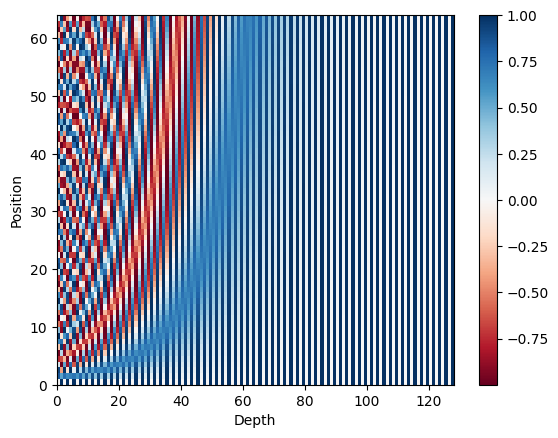

In [14]:
pe = pos_encoding_table(seq_length=64, d_model=128)
plt.pcolormesh(pe, cmap='RdBu')
plt.xlabel('Depth')
plt.xlim((0, d_model))
plt.ylabel('Position')
plt.colorbar()
plt.show()

In [15]:
type(pe)

numpy.ndarray

#### Position embedding 절차
1. 위에 구한 position encoding값(pe)를 사용해 position emgedding을 생성.
2. 학습되는 값이 아니므로 `freeze option`을 `True`로 설정.
3. 입력인 `inputs`과 동일한 크기를 갖는 텐서 `positions`을 생성한다.
4. `inputs` 내부에서 padding처리된 요소들(값이 0인 요소)을 찾아서 mask를 만든다.
5. `positions`에 mask를 적용한다.
6. `positions`에 해당하는 embedding을 구한다

In [16]:
from torch import nn
pe = torch.FloatTensor(pe)
nn_pos = nn.Embedding.from_pretrained(pe, freeze=True)
positions = torch.arange(inputs.size(1), device=inputs.device, dtype=inputs.dtype).expand(inputs.size(0), inputs.size(1)).contiguous() + 1
pos_mask = inputs.eq(0)

positions.masked_fill_(pos_mask, 0)
pos_embs = nn_pos(positions) # position embedding

print(inputs)
print(positions)
print(pos_embs.size())

tensor([[1147, 3680, 3899,  547,   86, 3890, 3643,  206,  100, 3586,  138, 4392,
          671, 1229, 4992, 3925, 1383, 3645,    0,    0],
        [2805, 1074,  290,  891, 2869, 3679, 3657,  264, 3654, 3661, 3642, 5114,
         3798, 3812, 3645,    0,    0,    0,    0,    0],
        [3355,   28, 3758, 1147, 3680, 3899, 3665,  522, 3795, 4383, 3646, 1047,
         4198, 3807,   18, 1393, 3852, 3812, 4326,    0]])
tensor([[ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18,
          0,  0],
        [ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15,  0,  0,  0,
          0,  0],
        [ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18,
         19,  0]])
torch.Size([3, 20, 128])


In [20]:
pos_embs[0]

tensor([[ 8.4147e-01,  5.4030e-01,  7.6172e-01,  ...,  1.0000e+00,
          1.1548e-04,  1.0000e+00],
        [ 9.0930e-01, -4.1615e-01,  9.8705e-01,  ...,  1.0000e+00,
          2.3096e-04,  1.0000e+00],
        [ 1.4112e-01, -9.8999e-01,  5.1731e-01,  ...,  1.0000e+00,
          3.4643e-04,  1.0000e+00],
        ...,
        [-7.5099e-01,  6.6032e-01,  1.2031e-01,  ...,  1.0000e+00,
          2.0786e-03,  1.0000e+00],
        [ 0.0000e+00,  1.0000e+00,  0.0000e+00,  ...,  1.0000e+00,
          0.0000e+00,  1.0000e+00],
        [ 0.0000e+00,  1.0000e+00,  0.0000e+00,  ...,  1.0000e+00,
          0.0000e+00,  1.0000e+00]])

### Position embedding된 입력

In [21]:
input_sums = input_embs + pos_embs

## 3. Scaled Dot Product Attention

In [22]:
inputs.shape

torch.Size([3, 20])

### Attention Mask

In [23]:
Q = input_sums
K = input_sums
V = input_sums

attn_mask = inputs.eq(0).unsqueeze(1).expand(Q.size(0), Q.size(1), K.size(1))
print(attn_mask.size())
print(attn_mask[0])

torch.Size([3, 20, 20])
tensor([[False, False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False,  True,  True],
        [False, False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False,  True,  True],
        [False, False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False,  True,  True],
        [False, False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False,  True,  True],
        [False, False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False,  True,  True],
        [False, False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False,  True,  True],
        [False, False,

`attn_mask` 계산 과정 설명:
1. 최초 `inputs`의 차원은 (batch_size, seq_length) = (3,20)이다.
2. `Q`, `K` 및 `V`의 차원은 (batch_size, seq_length, d_model) = (3, 20, 128)이다.
3. `attn_mask`의 크기는 (batch_size, seq_length, seq_length) = (3,20, 20) 이 되어야 한다.
4. inputs.eq(0) : padding된 0 이 있는 위치에서만 True이고 나머지는 False인 (3,20) 텐서.
5. inputs.eq(0).unsqueeze(1) : dim(또는 axis) 추가하여 (3,1,20) 텐서를 만들고
6. expand(Q.size(0), Q.size(1), K.size(1)) : 0-dim 자리는 3인데 Q.size(0)=3 이므로 그대로 두고, 1-dim은 1인데 Q.size(1)=20 이므로 복사 확장, 2-dim은 20인데 K.size(1)=20 이므로 그대로 둔다.
- <span style="color:IndianRed">**[주의]**</span> size가 1이 아닌 dim을 확장하려고 하면 오류.

### matmul(Q, K-transpose)
PyTorch tensor의 곱셈 연산 원리를 확실히 알고 있어야 한다.

#### 3rd-order 이상($k \times l \times m \times \cdots$)의 텐서 연산
- `dot(Q, K)`는 Q의 마지막 axis와 K의 마지막에서 두번째 axis끼리 곱한 결과를 반영
- `matmul(Q, K)` 또는 `Q @ K`는, Q의 마지막 두 axis 차원이 (..., m, p), K의 마지막 두 axis 차원이 (..., p, n)라고 하면, 이 사이에서만 곱하여 (..., n, m) 차원이 된다.<br>
  **(예)** (8 x 12 x 30 x 100) @ ((8 x 12 x 30 x 100) ⟹ (... 30 x 100) @ (... 30 x 100) <br>
⟹  차원이 맞지 않으므로 마지막 두 차원을 `transpose(-2, -1)` 한다 <br>
⟹  (8 x 12 x 30 x 100) @ ((8 x 12 x 100 x 30) ⟹ (... 30 x 100) @ (... 100 x 30)
⟹  (8 x 12 x 30 x 30)

In [24]:
scores = torch.matmul(Q, K.transpose(-1, -2))
print(scores.size())
print(scores[0])

torch.Size([3, 20, 20])
tensor([[217.7012,  70.2867,  61.8823,  51.9708,  49.9671,  54.2151,  22.6448,
          57.0849,  56.2180,  15.9864,  64.3747,  50.0599,  39.0273,  47.1519,
          44.3811,  45.5422,  59.7249,  46.3925,  86.5753,  86.5753],
        [ 70.2867, 171.2187,  43.6614,  59.6816,  43.6919,  65.7444,  52.0015,
          54.7327,  50.7590,  46.0818,  56.1158,  31.4820,  42.9526,  67.6481,
          40.6927,  39.6817,  69.8325,  34.0294,  57.0257,  57.0257],
        [ 61.8823,  43.6614, 184.8265,  38.6831,  45.1994,  25.7424,  33.1246,
          39.2106,  25.4425,  34.2747,  46.5936,  33.6230,  33.1403,  41.9300,
          27.3597,  46.6996,  61.4324,  37.1021,  75.0003,  75.0003],
        [ 51.9708,  59.6816,  38.6831, 165.0731,  55.7124,  42.0674,  29.9291,
          40.0010,  47.4783,  12.0903,  52.6433,  41.3439,  25.8947,  36.9013,
          32.6271,  18.1763,  52.5805,  33.1054,  37.7983,  37.7983],
        [ 49.9671,  43.6919,  45.1994,  55.7124, 170.0030,  44.1

### Scaling

In [14]:
d_k = 64
scores = scores.mul_(1/d_k**0.5)  # inplace operations
print(scores.size())
print(scores[0])

torch.Size([3, 20, 20])
tensor([[21.3913,  8.5425,  7.4212,  8.5373,  5.4836,  6.6972,  6.3825,  3.8660,
          5.8403,  3.4805,  6.1385,  6.8922,  5.1021,  9.5058,  9.5058,  9.5058,
          9.5058,  9.5058,  9.5058,  9.5058],
        [ 8.5425, 23.3129,  9.6231,  8.4160,  4.7200,  7.5310,  8.9851,  4.8176,
          5.4442,  5.4285,  4.2783,  6.5362,  5.3909,  7.4561,  7.4561,  7.4561,
          7.4561,  7.4561,  7.4561,  7.4561],
        [ 7.4212,  9.6231, 23.8440,  8.1367,  4.0386,  4.8204,  6.8145,  2.2520,
          7.9716,  3.4953,  4.0955,  4.7554,  1.3691,  9.4663,  9.4663,  9.4663,
          9.4663,  9.4663,  9.4663,  9.4663],
        [ 8.5373,  8.4160,  8.1367, 26.5018,  9.1392,  8.4478,  6.3778,  6.6539,
          7.1341,  5.7770,  9.4519,  7.0793,  3.9110,  6.8796,  6.8796,  6.8796,
          6.8796,  6.8796,  6.8796,  6.8796],
        [ 5.4836,  4.7200,  4.0386,  9.1392, 21.0901, 10.4522,  8.4138,  5.6996,
          5.7203,  6.6801,  7.7222,  5.2236,  3.5978,  6.4063, 

### Mask (Opt.)

In [25]:
float("-inf") < -1e9

True

In [26]:
scores.masked_fill_(attn_mask, float("-inf"))  # -1e9 보다 나을까?
print(scores.size())
print(scores[0])

torch.Size([3, 20, 20])
tensor([[217.7012,  70.2867,  61.8823,  51.9708,  49.9671,  54.2151,  22.6448,
          57.0849,  56.2180,  15.9864,  64.3747,  50.0599,  39.0273,  47.1519,
          44.3811,  45.5422,  59.7249,  46.3925,     -inf,     -inf],
        [ 70.2867, 171.2187,  43.6614,  59.6816,  43.6919,  65.7444,  52.0015,
          54.7327,  50.7590,  46.0818,  56.1158,  31.4820,  42.9526,  67.6481,
          40.6927,  39.6817,  69.8325,  34.0294,     -inf,     -inf],
        [ 61.8823,  43.6614, 184.8265,  38.6831,  45.1994,  25.7424,  33.1246,
          39.2106,  25.4425,  34.2747,  46.5936,  33.6230,  33.1403,  41.9300,
          27.3597,  46.6996,  61.4324,  37.1021,     -inf,     -inf],
        [ 51.9708,  59.6816,  38.6831, 165.0731,  55.7124,  42.0674,  29.9291,
          40.0010,  47.4783,  12.0903,  52.6433,  41.3439,  25.8947,  36.9013,
          32.6271,  18.1763,  52.5805,  33.1054,     -inf,     -inf],
        [ 49.9671,  43.6919,  45.1994,  55.7124, 170.0030,  44.1

### Softmax

In [38]:
attn_prob = nn.Softmax(dim=-1)(scores)
print(attn_prob.size())
print(attn_prob[0])

torch.Size([3, 20, 20])
tensor([[1.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
         0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
         0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
         0.0000e+00, 0.0000e+00],
        [1.4013e-44, 1.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
         0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
         0.0000e+00, 1.4013e-45, 0.0000e+00, 0.0000e+00, 9.8091e-45, 0.0000e+00,
         0.0000e+00, 0.0000e+00],
        [0.0000e+00, 0.0000e+00, 1.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
         0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
         0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
         0.0000e+00, 0.0000e+00],
        [0.0000e+00, 0.0000e+00, 0.0000e+00, 1.0000e+00, 0.0000e+00, 0.0000e+00,
         0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e

- Mask로 float("-inf") 또는 -1e9 를 사용한 경우 모두 mask된 값들이 0이 됨

In [39]:
V.shape

torch.Size([3, 20, 128])

### matmul(attn_prob, V)

In [40]:
context = torch.matmul(attn_prob, V)  # (3, 20, 20) x (3, 20, 128)
print(context.size())

torch.Size([3, 20, 128])


### ScaledDotProductAttention Class 화
- 앞에서는 Q, K, V 가 rank=3 인 텐서인 경우의 코딩이었다.
- `ScaledDotProductAttention` class는 Multihead Attention을 고려하여 rank=4인 텐서를 다룬다.

In [41]:
class ScaledDotProductAttention(nn.Module):
    def __init__(self, d_k):
        super().__init__()
        self.scale = 1 / (d_k ** 0.5)  # d_k : head의 크기(차원), d_k = d_model // num_head
    
    def forward(self, Q, K, V, attn_mask):
        # Q, K, V : (batch_size, num_head, seq_length, d_k)  
        # scores: (batch_size, num_head, seq_length, seq_length)
        scores = torch.matmul(Q, K.transpose(-1, -2)).mul_(self.scale) 
        scores.masked_fill_(attn_mask, -1e9)
        attn_prob = nn.Softmax(dim=-1)(scores)  # (batch_size, num_head, seq_length, seq_length)
        context = torch.matmul(attn_prob, V)    # (batch_size, num_head, seq_length, d_k)
        return context, attn_prob

## 4. Multi-Head Attention

In [42]:
Q = input_sums # (batch_size, num_head, seq_length, d_model)
K = input_sums
V = input_sums
attn_mask = inputs.eq(0).unsqueeze(1).expand(Q.size(0), Q.size(1), K.size(1))
batch_size = Q.size(0)
num_head = 2

### Multi Head Q, K, V 입력

In [44]:
d_k = d_model // num_head
W_q = nn.Linear(d_model, num_head * d_k)  # = nn.Linear(d_model, d_model)
W_k = nn.Linear(d_model, num_head * d_k)
W_v = nn.Linear(d_model, num_head * d_k)

q_s = W_q(Q)  # (batch_size, seq_length, num_head * d_k)
q_s = q_s.view(batch_size, -1, num_head, d_k)  # (batch_size, seq_length, num_head, d_k)
q_s = q_s.transpose(1,2)  # (batch_size, num_head, seq_length, d_k)

In [45]:
print(q_s.size())

torch.Size([3, 2, 20, 64])


#### 위의 과정을 간략히 표현하면

In [46]:
q_s = W_q(Q).view(batch_size, -1, num_head, d_k).transpose(1,2)
k_s = W_k(K).view(batch_size, -1, num_head, d_k).transpose(1,2)
v_s = W_v(V).view(batch_size, -1, num_head, d_k).transpose(1,2)
print(q_s.size(), k_s.size(), v_s.size())

torch.Size([3, 2, 20, 64]) torch.Size([3, 2, 20, 64]) torch.Size([3, 2, 20, 64])


### Attention Mask도 Multi Head로 변경

In [47]:
print(attn_mask.size())
attn_mask = attn_mask.unsqueeze(1).repeat(1, num_head, 1, 1)
print(attn_mask.size())

torch.Size([3, 20, 20])
torch.Size([3, 2, 20, 20])


### Attention

In [48]:
scaled_dot_attn = ScaledDotProductAttention(d_k)
context, attn_prob = scaled_dot_attn(q_s, k_s, v_s, attn_mask)
print(context.size())
print(attn_prob.size())

torch.Size([3, 2, 20, 64])
torch.Size([3, 2, 20, 20])


### Concat

In [49]:
# (batch_size, seq_length, num_head * d_k)
context = context.transpose(1, 2).contiguous().view(batch_size, -1, num_head * d_k)
print(context.size())

torch.Size([3, 20, 128])


### Linear

In [50]:
linear = nn.Linear(num_head * d_k, d_model)
# (batch_size, seq_length, d_model)
output = linear(context)
print(output.size())

torch.Size([3, 20, 128])


### 앞의 코드들을 Class 화

In [51]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_head, d_k):
        super().__init__()
        self.d_model = d_model
        self.num_head = num_head
        self.d_k = d_k

        self.W_q = nn.Linear(d_model, num_head * d_k)
        self.W_k = nn.Linear(d_model, num_head * d_k)
        self.W_v = nn.Linear(d_model, num_head * d_k)
        self.scaled_dot_attn = ScaledDotProductAttention(d_k)
        self.linear = nn.Linear(num_head * d_k, d_model)
    
    def forward(self, Q, K, V, attn_mask):
        batch_size = Q.size(0)
        q_s = self.W_q(Q).view(batch_size, -1, self.num_head, self.d_k).transpose(1,2)
        k_s = self.W_k(K).view(batch_size, -1, self.num_head, self.d_k).transpose(1,2)
        v_s = self.W_v(V).view(batch_size, -1, self.num_head, self.d_k).transpose(1,2)
        attn_mask = attn_mask.unsqueeze(1).repeat(1, self.num_head, 1, 1)
        context, attn_prob = self.scaled_dot_attn(q_s, k_s, v_s, attn_mask)
        context = context.transpose(1, 2).contiguous().view(batch_size, -1, self.num_head * self.d_k)
        output = self.linear(context)
        return output, attn_prob

## 5. Masked Multi-Head Attention
- attention mask 부분을 제외한 나머지는 Multi-Head Attention과 모두 동일함.

### Decoder attention mask

In [55]:
def antipeep_future_mask(seq):
    antipeep_mask = torch.ones_like(seq).unsqueeze(-1).expand(seq.size(0), seq.size(1), seq.size(1))
    antipeep_mask = antipeep_mask.triu(diagonal=1) # upper triangular part of a matrix(2-D)
    return antipeep_mask # (batch_size, seq_length, seq_length)

In [56]:
Q = input_sums
K = input_sums
V = input_sums

attn_pad_mask = inputs.eq(0).unsqueeze(1).expand(Q.size(0), Q.size(1), K.size(1))
attn_dec_mask = antipeep_future_mask(inputs)  # (batch_size, seq_length, seq_length)
attn_mask = torch.gt((attn_pad_mask + attn_dec_mask), 0)  # greater tha zero?

print(attn_pad_mask[1])
print(attn_dec_mask[1])
print(attn_mask[1])

batch_size = Q.size(0)
num_head = 2

tensor([[False, False, False, False, False, False, False, False, False, False,
         False, False, False, False, False,  True,  True,  True,  True,  True],
        [False, False, False, False, False, False, False, False, False, False,
         False, False, False, False, False,  True,  True,  True,  True,  True],
        [False, False, False, False, False, False, False, False, False, False,
         False, False, False, False, False,  True,  True,  True,  True,  True],
        [False, False, False, False, False, False, False, False, False, False,
         False, False, False, False, False,  True,  True,  True,  True,  True],
        [False, False, False, False, False, False, False, False, False, False,
         False, False, False, False, False,  True,  True,  True,  True,  True],
        [False, False, False, False, False, False, False, False, False, False,
         False, False, False, False, False,  True,  True,  True,  True,  True],
        [False, False, False, False, False, Fa

In [63]:
a = torch.ones(20, 20, dtype=torch.int)
a.masked_fill_(attn_mask[1], 0)  
a

tensor([[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0],
        [1, 1, 1, 1,

### Multi-Head Attention
- 나머지는 Encoder의 MultiHead Attention과 동일하므로 앞에서 선언한 MultiHeadAttention 클래스를 바로 호출 

In [64]:
attention = MultiHeadAttention(d_model, num_head, d_k)
output, attn_prob = attention(Q, K, V, attn_mask)
print(output.size(), attn_prob.size())

torch.Size([3, 20, 128]) torch.Size([3, 2, 20, 20])


## 6. FeeedForward
- 비선형성 추가
- $f_2 = W_2\mathrm {ReLU}(f_1 = xW_1 + b_1) + b_2$
- 최근부터, ReLU 보다는 GELU(Gaussian Error Linear Units)의 성능이 더 좋다는 것이 밝혀짐

$f_1 = xW_1 + b_1$

In [65]:
import torch.nn.functional as F

conv1 = nn.Conv1d(in_channels=d_model, out_channels=d_model * 4, kernel_size=1)
ff_1 = conv1(output.transpose(1, 2))  # (batch_size, d_model * 4, seq_length)
print(ff_1.size())

torch.Size([3, 512, 20])


#### Nonlinear Activation (relu or gelu)
<img src="images/GELU _ReLU.png" width="300" style="margin-left: auto; margin-right: auto">
<p style="text-align: center;">ReLU, ELU 및 GELU</p>

In [66]:
active = F.gelu  # 또는 F.relu
ff_2 = active(ff_1)

$f_3 = f_2W_2 + b_2$

In [69]:
conv2 = nn.Conv1d(in_channels=d_model * 4, out_channels=d_model, kernel_size=1)
ff_3 = conv2(ff_2).transpose(1, 2)  # (batch_size, seq_length, d_model)
print(ff_3.size())

torch.Size([3, 20, 128])


### Class로 정리

In [70]:
class PositionwiseFeedForward(nn.Module):
    def __init__(self, d_model):
        super().__init__()

        self.conv1 = nn.Conv1d(in_channels=self.config.d_model, out_channels=self.config.d_model * 4, kernel_size=1)
        self.conv2 = nn.Conv1d(in_channels=self.config.d_model * 4, out_channels=self.config.d_model, kernel_size=1)
        self.active = nn.GELU

    def forward(self, inputs):
        output = self.active(self.conv1(inputs.transpose(1, 2)))  # (batch_size, d_model * 4, seq_length)
        output = self.active(output)
        output = self.conv2(output).transpose(1, 2)  # (batch_size, seq_length, d_model)
        return output